# 09 - Conclusiones generales del EDA

Este notebook consolida los principales hallazgos del análisis exploratorio de datos realizado sobre la base de ventas de Olímpica.

El objetivo es cerrar el EDA con una lectura ejecutiva y técnica sobre:

- Estructura general de la base.
- Calidad de datos.
- Comportamiento temporal.
- Diferencias por PDV.
- Composición por categorías y productos.
- Impacto de promociones y descuentos.
- Comportamiento de tickets.
- Outliers y casos especiales.
- Recomendaciones para el modelado predictivo.
- Granularidad recomendada para el proyecto.

Este notebook no busca repetir todos los análisis anteriores, sino resumir los resultados más importantes y dejar una guía clara para la siguiente fase del proyecto.

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

CONCLUSIONES_FIGURES_DIR = FIGURES_DIR / "conclusiones"

PROCESSED_FILE = PROCESSED_DIR / "ventas_eda.parquet"
TICKETS_FILE = PROCESSED_DIR / "tickets_eda.parquet"
VALIDOS_FILE = PROCESSED_DIR / "ventas_validos_basicos.parquet"
REGISTROS_ESPECIALES_FILE = PROCESSED_DIR / "registros_especiales.parquet"

CONCLUSIONES_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo principal:")
print(PROCESSED_FILE)

print("\n¿Existe el archivo principal?")
print(PROCESSED_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo principal:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_eda.parquet

¿Existe el archivo principal?
True


In [3]:
# ===============================
# Cargar base principal
# ===============================

df = pd.read_parquet(PROCESSED_FILE)
df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

print("Base principal cargada correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Base principal cargada correctamente.
Filas: 409,760
Columnas: 54


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
0,4,2023-01-01,980,4,0,1,04010,1280454,3.00,298.00,0.00,10,44927,0,298.00,0.00,99.33,99.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,12,2023-01-01,1255,4,0,2,04010,1328730,1.00,115.00,0.00,10,44927,0,115.00,0.00,115.00,115.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,24,2023-01-01,1255,4,0,3,04010,1036266,3.00,448.00,0.00,10,44927,0,448.00,0.00,149.33,149.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,36,2023-01-01,1311,6,0,4,08061,1265857,1.00,82.00,0.00,11,44927,0,82.00,0.00,82.00,82.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1311_4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,37,2023-01-01,980,4,0,5,04010,1328946,4.00,519.00,0.00,10,44927,0,519.00,0.00,129.75,129.75,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True


In [4]:
# ===============================
# Cargar bases auxiliares si existen
# ===============================

def cargar_parquet_si_existe(path):
    if path.exists():
        return pd.read_parquet(path)
    else:
        print(f"No existe: {path.name}")
        return None

tickets = cargar_parquet_si_existe(TICKETS_FILE)
df_validos = cargar_parquet_si_existe(VALIDOS_FILE)
df_especiales = cargar_parquet_si_existe(REGISTROS_ESPECIALES_FILE)

if tickets is not None:
    print(f"Tickets cargados: {tickets.shape[0]:,} filas")

if df_validos is not None:
    print(f"Registros válidos cargados: {df_validos.shape[0]:,} filas")

if df_especiales is not None:
    print(f"Registros especiales cargados: {df_especiales.shape[0]:,} filas")

Tickets cargados: 276,989 filas
Registros válidos cargados: 398,537 filas
Registros especiales cargados: 13,497 filas


In [5]:
# ===============================
# Resumen general del EDA
# ===============================

resumen_general_eda = pd.DataFrame({
    "aspecto": [
        "Filas totales",
        "Columnas totales",
        "Fecha mínima",
        "Fecha máxima",
        "Días únicos",
        "Años disponibles",
        "PDV únicos",
        "Estratos únicos",
        "Categorías únicas",
        "Grupos comerciales únicos",
        "Productos únicos",
        "Facturas únicas globales",
        "Tickets únicos",
        "Venta bruta total",
        "Descuento total",
        "Venta neta total",
        "Unidades totales",
        "Porcentaje descuento sobre venta bruta",
        "Líneas promocionales",
        "Porcentaje líneas promocionales",
        "Registros especiales",
        "Porcentaje registros especiales",
        "Registros válidos básicos",
        "Porcentaje registros válidos básicos"
    ],
    "valor": [
        len(df),
        df.shape[1],
        df["FECHA"].min(),
        df["FECHA"].max(),
        df["FECHA"].nunique(),
        df["ANIO"].nunique(),
        df["PDV"].nunique(),
        df["Estrato"].nunique(),
        df["CATEG"].nunique(),
        df["GRUCOM"].nunique(),
        df["PLU_SAP"].nunique(),
        df["FACTURA"].nunique(),
        df["TICKET_ID"].nunique(),
        df["VENTA"].sum(),
        df["DESCUENTO"].sum(),
        df["VENTA_NETA"].sum(),
        df["CANT"].sum(),
        df["DESCUENTO"].sum() / df["VENTA"].sum() * 100,
        df["PROMO_FLAG"].sum(),
        df["PROMO_FLAG"].mean() * 100,
        df["REGISTRO_ESPECIAL"].sum(),
        df["REGISTRO_ESPECIAL"].mean() * 100,
        df["REGISTRO_VALIDO_BASICO"].sum(),
        df["REGISTRO_VALIDO_BASICO"].mean() * 100
    ]
})

resumen_general_eda

,aspecto,valor
0,Filas totales,409760
1,Columnas totales,54
2,Fecha mínima,2023-01-01 00:00:00
3,Fecha máxima,2024-12-31 00:00:00
4,Días únicos,731
5,Años disponibles,2
6,PDV únicos,3
7,Estratos únicos,2
8,Categorías únicas,7
9,Grupos comerciales únicos,2


In [6]:
# ===============================
# Resumen anual
# ===============================

resumen_anual = (
    df.groupby("ANIO")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum")
    )
    .reset_index()
)

resumen_anual["descuento_pct"] = np.where(
    resumen_anual["venta_bruta"] > 0,
    resumen_anual["descuento"] / resumen_anual["venta_bruta"] * 100,
    np.nan
)

resumen_anual["promo_pct_lineas"] = np.where(
    resumen_anual["filas"] > 0,
    resumen_anual["lineas_promo"] / resumen_anual["filas"] * 100,
    np.nan
)

resumen_anual["ticket_promedio_neto"] = np.where(
    resumen_anual["tickets"] > 0,
    resumen_anual["venta_neta"] / resumen_anual["tickets"],
    np.nan
)

resumen_anual

,ANIO,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,registros_especiales,descuento_pct,promo_pct_lineas,ticket_promedio_neto
0,2023,228150,365,"78,121,622.00","9,775,494.00","68,346,128.00","278,784.76",152896,5410,65612,7971,12.51,28.76,447.01
1,2024,181610,366,"61,340,876.00","6,494,642.00","54,846,234.00","216,188.47",124093,4845,43627,5526,10.59,24.02,441.98


In [7]:
# ===============================
# Resumen por PDV
# ===============================

resumen_pdv = (
    df.groupby(["PDV", "Estrato"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        categorias=("CATEG", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum")
    )
    .reset_index()
)

resumen_pdv["participacion_venta_neta_pct"] = (
    resumen_pdv["venta_neta"] / resumen_pdv["venta_neta"].sum() * 100
)

resumen_pdv["ticket_promedio_neto"] = np.where(
    resumen_pdv["tickets"] > 0,
    resumen_pdv["venta_neta"] / resumen_pdv["tickets"],
    np.nan
)

resumen_pdv["promo_pct_lineas"] = np.where(
    resumen_pdv["filas"] > 0,
    resumen_pdv["lineas_promo"] / resumen_pdv["filas"] * 100,
    np.nan
)

resumen_pdv["registros_especiales_pct"] = np.where(
    resumen_pdv["filas"] > 0,
    resumen_pdv["registros_especiales"] / resumen_pdv["filas"] * 100,
    np.nan
)

resumen_pdv = resumen_pdv.sort_values("venta_neta", ascending=False)

resumen_pdv

,PDV,Estrato,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,productos,categorias,lineas_promo,registros_especiales,participacion_venta_neta_pct,ticket_promedio_neto,promo_pct_lineas,registros_especiales_pct
1,1311,6,201432,731,"80,638,414.00","8,777,219.00","71,861,195.00","232,738.60",129256,5142,7,57887,6028,58.33,555.96,28.74,2.99
0,1255,4,132627,731,"38,023,322.00","5,281,154.00","32,742,168.00","165,580.55",93693,3736,7,33129,4191,26.58,349.46,24.98,3.16
2,980,4,75701,731,"20,800,762.00","2,211,763.00","18,588,999.00","96,654.08",54040,2461,6,18223,3278,15.09,343.99,24.07,4.33


In [8]:
# ===============================
# Resumen por categoría
# ===============================

resumen_categoria = (
    df.groupby(["GRUCOM", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum")
    )
    .reset_index()
)

resumen_categoria["participacion_venta_neta_pct"] = (
    resumen_categoria["venta_neta"] / resumen_categoria["venta_neta"].sum() * 100
)

resumen_categoria["promo_pct_lineas"] = np.where(
    resumen_categoria["filas"] > 0,
    resumen_categoria["lineas_promo"] / resumen_categoria["filas"] * 100,
    np.nan
)

resumen_categoria["descuento_pct"] = np.where(
    resumen_categoria["venta_bruta"] > 0,
    resumen_categoria["descuento"] / resumen_categoria["venta_bruta"] * 100,
    np.nan
)

resumen_categoria = resumen_categoria.sort_values("venta_neta", ascending=False)

resumen_categoria

,GRUCOM,CATEG,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,registros_especiales,participacion_venta_neta_pct,promo_pct_lineas,descuento_pct
0,10,04010,158659,731,"61,096,386.00","7,317,028.00","53,779,358.00","244,163.00",121604,1173,32262,9111,43.65,20.33,11.98
3,11,08042,52788,731,"29,985,976.00","2,868,994.00","27,116,982.00","60,593.26",41127,1748,16647,902,22.01,31.54,9.57
2,11,08029,132505,731,"29,011,472.00","3,044,652.00","25,966,820.00","123,061.92",95594,1391,40592,2167,21.08,30.63,10.49
4,11,08061,53538,731,"10,970,778.00","816,908.00","10,153,870.00","54,349.08",42098,804,13414,741,8.24,25.06,7.45
5,11,08062,10997,723,"7,667,928.00","2,222,411.00","5,445,517.00","10,972.18",8608,666,6321,528,4.42,57.48,28.98
6,11,08067,876,304,"698,356.00",143.00,"698,213.00","1,373.79",355,255,3,47,0.57,0.34,0.02
1,10,04019,397,288,"31,602.00",0.00,"31,602.00",460.00,392,2,0,1,0.03,0.00,0.00


In [9]:
# ===============================
# Resumen por producto
# ===============================

resumen_productos = (
    df.groupby("PLU_SAP")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        pdv=("PDV", "nunique"),
        categoria_principal=("CATEG", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum")
    )
    .reset_index()
)

resumen_productos["participacion_venta_neta_pct"] = (
    resumen_productos["venta_neta"] / resumen_productos["venta_neta"].sum() * 100
)

resumen_productos["promo_pct_lineas"] = np.where(
    resumen_productos["filas"] > 0,
    resumen_productos["lineas_promo"] / resumen_productos["filas"] * 100,
    np.nan
)

resumen_productos["precio_unitario_neto_promedio"] = np.where(
    resumen_productos["unidades"] > 0,
    resumen_productos["venta_neta"] / resumen_productos["unidades"],
    np.nan
)

resumen_productos = resumen_productos.sort_values("venta_neta", ascending=False)

top_20_productos = resumen_productos.head(20)

top_20_productos

,PLU_SAP,filas,dias,pdv,categoria_principal,venta_bruta,descuento,venta_neta,unidades,tickets,lineas_promo,registros_especiales,participacion_venta_neta_pct,promo_pct_lineas,precio_unitario_neto_promedio
1513,1036246,7872,719,3,04010,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",7675,812,143,1.59,10.32,181.40
1518,1036266,4699,697,3,04010,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",4397,901,146,1.32,19.17,113.25
4657,1331944,2142,569,3,04010,"1,380,941.00","11,793.00","1,369,148.00","3,143.00",2117,96,5,1.11,4.48,435.62
4936,1338873,8419,701,3,04010,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",8064,1279,33,1.06,15.19,97.11
3166,1246431,842,79,3,08029,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",627,613,133,1.03,72.80,786.47
1515,1036252,5075,708,3,04010,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",4735,925,207,0.99,18.23,145.57
1516,1036253,2824,633,3,04010,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",2682,601,194,0.98,21.28,84.23
4155,1313279,4665,695,3,04010,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",4299,980,126,0.88,21.01,155.32
1324,1023807,663,345,3,04010,"1,113,652.00","118,599.00","995,053.00",771.00,615,243,20,0.81,36.65,"1,290.60"
1556,1041245,803,410,3,04010,"980,909.00","85,998.00","894,911.00","2,724.00",793,69,11,0.73,8.59,328.53


In [10]:
# ===============================
# Pareto de productos
# ===============================

productos_pareto = resumen_productos.sort_values("venta_neta", ascending=False).copy()

productos_pareto["venta_neta_acumulada"] = productos_pareto["venta_neta"].cumsum()
productos_pareto["participacion_acumulada_pct"] = (
    productos_pareto["venta_neta_acumulada"] / productos_pareto["venta_neta"].sum() * 100
)

productos_pareto["rank_producto"] = np.arange(1, len(productos_pareto) + 1)
productos_pareto["participacion_productos_pct"] = (
    productos_pareto["rank_producto"] / len(productos_pareto) * 100
)

productos_80 = productos_pareto[productos_pareto["participacion_acumulada_pct"] <= 80]

n_productos_80 = len(productos_80)
pct_productos_80 = n_productos_80 / len(productos_pareto) * 100

print(f"Total productos: {len(productos_pareto):,}")
print(f"Productos que explican hasta el 80% de la venta neta: {n_productos_80:,}")
print(f"Porcentaje de productos: {pct_productos_80:.2f}%")

productos_pareto.head(20)

Total productos: 6,039
Productos que explican hasta el 80% de la venta neta: 1,321
Porcentaje de productos: 21.87%


,PLU_SAP,filas,dias,pdv,categoria_principal,venta_bruta,descuento,venta_neta,unidades,tickets,lineas_promo,registros_especiales,participacion_venta_neta_pct,promo_pct_lineas,precio_unitario_neto_promedio,venta_neta_acumulada,participacion_acumulada_pct,rank_producto,participacion_productos_pct
1513,1036246,7872,719,3,04010,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",7675,812,143,1.59,10.32,181.40,"1,958,957.00",1.59,1,0.02
1518,1036266,4699,697,3,04010,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",4397,901,146,1.32,19.17,113.25,"3,586,835.00",2.91,2,0.03
4657,1331944,2142,569,3,04010,"1,380,941.00","11,793.00","1,369,148.00","3,143.00",2117,96,5,1.11,4.48,435.62,"4,955,983.00",4.02,3,0.05
4936,1338873,8419,701,3,04010,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",8064,1279,33,1.06,15.19,97.11,"6,267,724.00",5.09,4,0.07
3166,1246431,842,79,3,08029,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",627,613,133,1.03,72.80,786.47,"7,530,798.00",6.11,5,0.08
1515,1036252,5075,708,3,04010,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",4735,925,207,0.99,18.23,145.57,"8,756,387.00",7.11,6,0.10
1516,1036253,2824,633,3,04010,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",2682,601,194,0.98,21.28,84.23,"9,964,403.00",8.09,7,0.12
4155,1313279,4665,695,3,04010,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",4299,980,126,0.88,21.01,155.32,"11,047,173.00",8.97,8,0.13
1324,1023807,663,345,3,04010,"1,113,652.00","118,599.00","995,053.00",771.00,615,243,20,0.81,36.65,"1,290.60","12,042,226.00",9.78,9,0.15
1556,1041245,803,410,3,04010,"980,909.00","85,998.00","894,911.00","2,724.00",793,69,11,0.73,8.59,328.53,"12,937,137.00",10.50,10,0.17


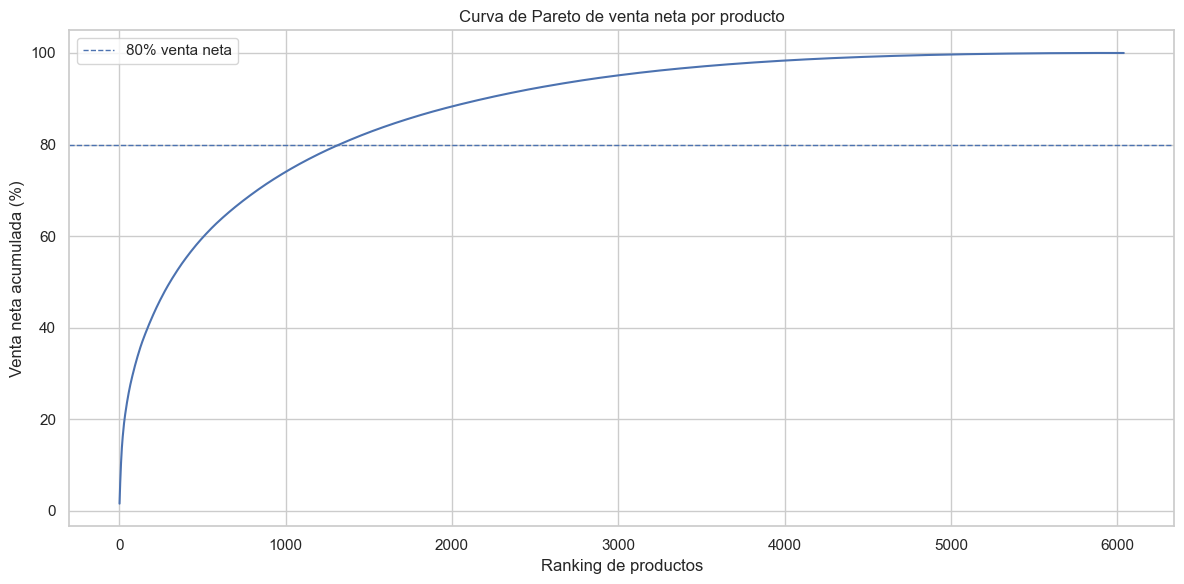

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\conclusiones\pareto_productos_conclusiones.png


In [11]:
# ===============================
# Gráfico Pareto de productos
# ===============================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=productos_pareto,
    x="rank_producto",
    y="participacion_acumulada_pct"
)

plt.axhline(80, linestyle="--", linewidth=1, label="80% venta neta")
plt.title("Curva de Pareto de venta neta por producto")
plt.xlabel("Ranking de productos")
plt.ylabel("Venta neta acumulada (%)")
plt.legend()
plt.tight_layout()

output_fig = CONCLUSIONES_FIGURES_DIR / "pareto_productos_conclusiones.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [12]:
# ===============================
# Resumen de promociones
# ===============================

resumen_promociones = pd.DataFrame({
    "metrica": [
        "Filas totales",
        "Filas con promoción",
        "% líneas promocionales",
        "Venta neta total",
        "Venta neta promocional",
        "% venta neta promocional",
        "Descuento total",
        "Descuento / venta bruta (%)",
        "Productos con promoción",
        "Categorías con promoción",
        "PDV con promoción"
    ],
    "valor": [
        len(df),
        df["PROMO_FLAG"].sum(),
        df["PROMO_FLAG"].mean() * 100,
        df["VENTA_NETA"].sum(),
        df.loc[df["PROMO_FLAG"], "VENTA_NETA"].sum(),
        df.loc[df["PROMO_FLAG"], "VENTA_NETA"].sum() / df["VENTA_NETA"].sum() * 100,
        df["DESCUENTO"].sum(),
        df["DESCUENTO"].sum() / df["VENTA"].sum() * 100,
        df.loc[df["PROMO_FLAG"], "PLU_SAP"].nunique(),
        df.loc[df["PROMO_FLAG"], "CATEG"].nunique(),
        df.loc[df["PROMO_FLAG"], "PDV"].nunique()
    ]
})

resumen_promociones

,metrica,valor
0,Filas totales,"409,760.00"
1,Filas con promoción,"109,239.00"
2,% líneas promocionales,26.66
3,Venta neta total,"123,192,362.00"
4,Venta neta promocional,"25,002,304.00"
5,% venta neta promocional,20.30
6,Descuento total,"16,270,136.00"
7,Descuento / venta bruta (%),11.67
8,Productos con promoción,"4,822.00"
9,Categorías con promoción,6.00


In [13]:
# ===============================
# Resumen de tickets
# ===============================

if tickets is not None:
    resumen_tickets = pd.DataFrame({
        "metrica": [
            "Tickets únicos",
            "Venta neta total",
            "Ticket promedio neto",
            "Ticket mediano neto",
            "Máximo ticket neto",
            "Mínimo ticket neto",
            "Promedio líneas por ticket",
            "Promedio productos por ticket",
            "Tickets con promoción",
            "% tickets con promoción",
            "Tickets con venta neta negativa",
            "Tickets con venta neta cero"
        ],
        "valor": [
            tickets["TICKET_ID"].nunique(),
            tickets["venta_neta"].sum(),
            tickets["venta_neta"].mean(),
            tickets["venta_neta"].median(),
            tickets["venta_neta"].max(),
            tickets["venta_neta"].min(),
            tickets["lineas"].mean(),
            tickets["productos_distintos"].mean(),
            tickets["promo_flag_ticket"].sum(),
            tickets["promo_flag_ticket"].mean() * 100,
            (tickets["venta_neta"] < 0).sum(),
            (tickets["venta_neta"] == 0).sum()
        ]
    })
else:
    resumen_tickets = pd.DataFrame()

resumen_tickets

,metrica,valor
0,Tickets únicos,"276,989.00"
1,Venta neta total,"123,192,362.00"
2,Ticket promedio neto,444.76
3,Ticket mediano neto,199.00
4,Máximo ticket neto,"195,457.00"
5,Mínimo ticket neto,"-8,160.00"
6,Promedio líneas por ticket,1.48
7,Promedio productos por ticket,1.41
8,Tickets con promoción,"70,215.00"
9,% tickets con promoción,25.35


In [14]:
# ===============================
# Resumen de calidad de datos
# ===============================

resumen_calidad = pd.DataFrame({
    "caso": [
        "Registros totales",
        "Registros especiales",
        "Registros válidos básicos",
        "Cantidad nula",
        "Cantidad cero",
        "Cantidad negativa",
        "Venta cero",
        "Venta negativa",
        "Descuento negativo",
        "Descuento mayor que venta",
        "Venta neta cero",
        "Venta neta negativa",
        "Precio unitario neto negativo"
    ],
    "cantidad": [
        len(df),
        df["REGISTRO_ESPECIAL"].sum(),
        df["REGISTRO_VALIDO_BASICO"].sum(),
        df["CANT"].isna().sum(),
        (df["CANT"] == 0).sum(),
        (df["CANT"] < 0).sum(),
        (df["VENTA"] == 0).sum(),
        (df["VENTA"] < 0).sum(),
        (df["DESCUENTO"] < 0).sum(),
        (df["DESCUENTO"] > df["VENTA"]).sum(),
        (df["VENTA_NETA"] == 0).sum(),
        (df["VENTA_NETA"] < 0).sum(),
        (df["PRECIO_UNITARIO_NETO"] < 0).sum()
    ]
})

resumen_calidad["porcentaje"] = resumen_calidad["cantidad"] / len(df) * 100

resumen_calidad

,caso,cantidad,porcentaje
0,Registros totales,409760,100.00
1,Registros especiales,13497,3.29
2,Registros válidos básicos,398537,97.26
3,Cantidad nula,180,0.04
4,Cantidad cero,2322,0.57
5,Cantidad negativa,133,0.03
6,Venta cero,3470,0.85
7,Venta negativa,1763,0.43
8,Descuento negativo,12,0.00
9,Descuento mayor que venta,8799,2.15


In [15]:
# ===============================
# Comparación base completa vs registros válidos básicos
# ===============================

df_validos_basicos = df[df["REGISTRO_VALIDO_BASICO"]].copy()

comparacion_base = pd.DataFrame({
    "metrica": [
        "Filas",
        "Venta bruta",
        "Descuento",
        "Venta neta",
        "Unidades",
        "Tickets",
        "Productos",
        "Categorías",
        "PDV"
    ],
    "base_completa": [
        len(df),
        df["VENTA"].sum(),
        df["DESCUENTO"].sum(),
        df["VENTA_NETA"].sum(),
        df["CANT"].sum(),
        df["TICKET_ID"].nunique(),
        df["PLU_SAP"].nunique(),
        df["CATEG"].nunique(),
        df["PDV"].nunique()
    ],
    "base_validos_basicos": [
        len(df_validos_basicos),
        df_validos_basicos["VENTA"].sum(),
        df_validos_basicos["DESCUENTO"].sum(),
        df_validos_basicos["VENTA_NETA"].sum(),
        df_validos_basicos["CANT"].sum(),
        df_validos_basicos["TICKET_ID"].nunique(),
        df_validos_basicos["PLU_SAP"].nunique(),
        df_validos_basicos["CATEG"].nunique(),
        df_validos_basicos["PDV"].nunique()
    ]
})

comparacion_base["diferencia"] = (
    comparacion_base["base_completa"] -
    comparacion_base["base_validos_basicos"]
)

comparacion_base["diferencia_pct"] = np.where(
    comparacion_base["base_completa"] != 0,
    comparacion_base["diferencia"] / comparacion_base["base_completa"] * 100,
    np.nan
)

comparacion_base

,metrica,base_completa,base_validos_basicos,diferencia,diferencia_pct
0,Filas,"409,760.00","398,537.00","11,223.00",2.74
1,Venta bruta,"139,462,498.00","138,809,582.00","652,916.00",0.47
2,Descuento,"16,270,136.00","12,483,843.00","3,786,293.00",23.27
3,Venta neta,"123,192,362.00","126,325,739.00","-3,133,377.00",-2.54
4,Unidades,"494,973.23","483,892.06","11,081.17",2.24
5,Tickets,"276,989.00","276,260.00",729.00,0.26
6,Productos,"6,039.00","5,973.00",66.00,1.09
7,Categorías,7.00,7.00,0.00,0.00
8,PDV,3.00,3.00,0.00,0.00


In [16]:
# ===============================
# Agregación día - PDV - producto
# ===============================

agg_dia_pdv_producto = (
    df.groupby(["FECHA", "PDV", "PLU_SAP"])
    .agg(
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas=("NroReg", "count"),
        categorias=("CATEG", "nunique"),
        promo_lineas=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

agg_dia_pdv_producto["promo_pct_lineas"] = np.where(
    agg_dia_pdv_producto["lineas"] > 0,
    agg_dia_pdv_producto["promo_lineas"] / agg_dia_pdv_producto["lineas"] * 100,
    np.nan
)

agg_dia_pdv_producto["registros_especiales_pct"] = np.where(
    agg_dia_pdv_producto["lineas"] > 0,
    agg_dia_pdv_producto["registros_especiales"] / agg_dia_pdv_producto["lineas"] * 100,
    np.nan
)

agg_dia_pdv_producto.head()

,FECHA,PDV,PLU_SAP,venta_bruta,descuento,venta_neta,unidades,tickets,lineas,categorias,promo_lineas,registros_especiales,registros_validos,promo_pct_lineas,registros_especiales_pct
0,2023-01-01,1255,1008762,0.00,0.00,0.00,0.00,1,1,1,0,1,0,0.00,100.00
1,2023-01-01,1255,1012222,119.00,0.00,119.00,1.00,1,1,1,0,0,1,0.00,0.00
2,2023-01-01,1255,1013410,376.00,0.00,376.00,1.00,1,1,1,0,0,1,0.00,0.00
3,2023-01-01,1255,1020600,246.00,0.00,246.00,1.00,1,1,1,0,0,1,0.00,0.00
4,2023-01-01,1255,1021469,233.00,0.00,233.00,1.00,1,1,1,0,0,1,0.00,0.00


In [17]:
# ===============================
# Agregación día - PDV - categoría
# ===============================

agg_dia_pdv_categoria = (
    df.groupby(["FECHA", "PDV", "CATEG"])
    .agg(
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas=("NroReg", "count"),
        productos=("PLU_SAP", "nunique"),
        promo_lineas=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

agg_dia_pdv_categoria["promo_pct_lineas"] = np.where(
    agg_dia_pdv_categoria["lineas"] > 0,
    agg_dia_pdv_categoria["promo_lineas"] / agg_dia_pdv_categoria["lineas"] * 100,
    np.nan
)

agg_dia_pdv_categoria["registros_especiales_pct"] = np.where(
    agg_dia_pdv_categoria["lineas"] > 0,
    agg_dia_pdv_categoria["registros_especiales"] / agg_dia_pdv_categoria["lineas"] * 100,
    np.nan
)

agg_dia_pdv_categoria.head()

,FECHA,PDV,CATEG,venta_bruta,descuento,venta_neta,unidades,tickets,lineas,productos,promo_lineas,registros_especiales,registros_validos,promo_pct_lineas,registros_especiales_pct
0,2023-01-01,1255,04010,"21,974.00",142.00,"21,832.00",126.00,57,79,37,2,2,79,2.53,2.53
1,2023-01-01,1255,08029,"2,100.00",51.00,"2,049.00",17.07,16,17,16,2,0,17,11.76,0.00
2,2023-01-01,1255,08061,0.00,0.00,0.00,0.00,1,1,1,0,1,0,0.00,100.00
3,2023-01-01,1311,04010,"6,497.00",674.00,"5,823.00",31.00,12,20,18,4,0,20,20.00,0.00
4,2023-01-01,1311,08029,"3,981.00",12.00,"3,969.00",22.39,17,24,22,2,0,24,8.33,0.00


In [18]:
# ===============================
# Comparación de granularidades para modelado
# ===============================

comparacion_granularidad = pd.DataFrame({
    "granularidad": [
        "Línea transaccional",
        "Día - PDV - Producto",
        "Día - PDV - Categoría",
        "Día - PDV",
        "Día total"
    ],
    "numero_filas": [
        len(df),
        len(agg_dia_pdv_producto),
        len(agg_dia_pdv_categoria),
        df.groupby(["FECHA", "PDV"]).size().reset_index().shape[0],
        df.groupby(["FECHA"]).size().reset_index().shape[0]
    ],
    "nivel_detalle": [
        "Muy alto",
        "Alto",
        "Medio",
        "Bajo",
        "Muy bajo"
    ],
    "ventaja": [
        "Conserva toda la información original",
        "Permite modelar ventas por SKU y tienda",
        "Reduce ruido y alta cardinalidad de productos",
        "Bueno para análisis operativo por tienda",
        "Bueno para tendencia general"
    ],
    "desventaja": [
        "No es ideal directamente para series de tiempo",
        "Alta cantidad de combinaciones y muchos ceros posibles",
        "Pierde detalle por producto",
        "Pierde categoría y producto",
        "Pierde PDV, categoría y producto"
    ],
    "uso_recomendado": [
        "Auditoría, limpieza y EDA base",
        "Modelado detallado si se quieren predecir SKUs",
        "Modelado inicial recomendado",
        "Seguimiento gerencial por tienda",
        "Resumen ejecutivo general"
    ]
})

comparacion_granularidad

,granularidad,numero_filas,nivel_detalle,ventaja,desventaja,uso_recomendado
0,Línea transaccional,409760,Muy alto,Conserva toda la información original,No es ideal directamente para series de tiempo,"Auditoría, limpieza y EDA base"
1,Día - PDV - Producto,286399,Alto,Permite modelar ventas por SKU y tienda,Alta cantidad de combinaciones y muchos ceros ...,Modelado detallado si se quieren predecir SKUs
2,Día - PDV - Categoría,11041,Medio,Reduce ruido y alta cardinalidad de productos,Pierde detalle por producto,Modelado inicial recomendado
3,Día - PDV,2193,Bajo,Bueno para análisis operativo por tienda,Pierde categoría y producto,Seguimiento gerencial por tienda
4,Día total,731,Muy bajo,Bueno para tendencia general,"Pierde PDV, categoría y producto",Resumen ejecutivo general


In [19]:
# ===============================
# Recomendación automática según estructura observada
# ===============================

n_productos = df["PLU_SAP"].nunique()
n_categorias = df["CATEG"].nunique()
n_pdv = df["PDV"].nunique()
n_dias = df["FECHA"].nunique()

filas_producto = len(agg_dia_pdv_producto)
filas_categoria = len(agg_dia_pdv_categoria)

resumen_granularidad = pd.DataFrame({
    "indicador": [
        "Productos únicos",
        "Categorías únicas",
        "PDV únicos",
        "Días únicos",
        "Filas día-PDV-producto",
        "Filas día-PDV-categoría",
        "Relación filas producto / filas categoría"
    ],
    "valor": [
        n_productos,
        n_categorias,
        n_pdv,
        n_dias,
        filas_producto,
        filas_categoria,
        filas_producto / filas_categoria if filas_categoria != 0 else np.nan
    ]
})

resumen_granularidad

,indicador,valor
0,Productos únicos,"6,039.00"
1,Categorías únicas,7.00
2,PDV únicos,3.00
3,Días únicos,731.00
4,Filas día-PDV-producto,"286,399.00"
5,Filas día-PDV-categoría,"11,041.00"
6,Relación filas producto / filas categoría,25.94


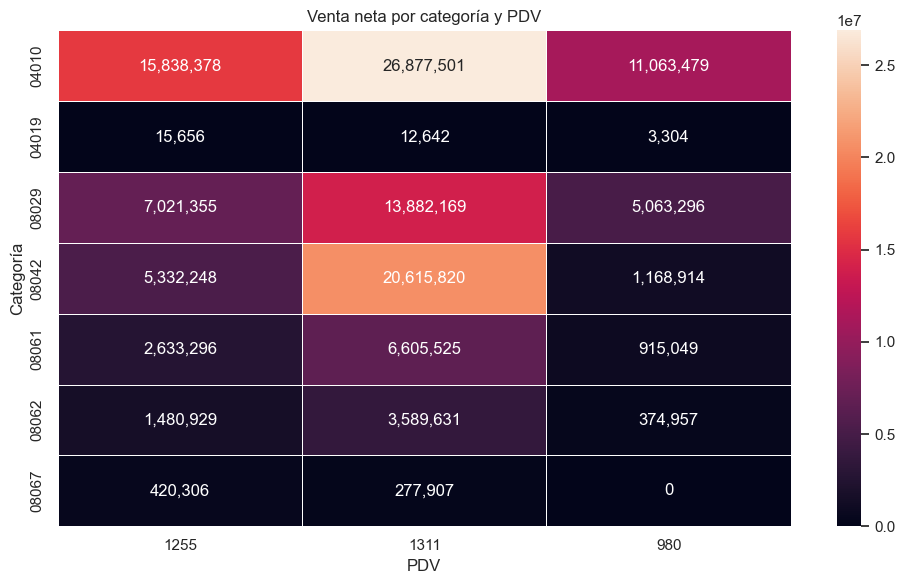

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\conclusiones\heatmap_venta_categoria_pdv_conclusiones.png


In [20]:
# ===============================
# Gráfico resumen PDV y categoría
# ===============================

resumen_cat_pdv = (
    df.groupby(["PDV", "CATEG"])
    .agg(venta_neta=("VENTA_NETA", "sum"))
    .reset_index()
)

tabla_cat_pdv = resumen_cat_pdv.pivot_table(
    index="CATEG",
    columns="PDV",
    values="venta_neta",
    fill_value=0
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_cat_pdv,
    annot=True,
    fmt=",.0f",
    linewidths=0.5
)

plt.title("Venta neta por categoría y PDV")
plt.xlabel("PDV")
plt.ylabel("Categoría")
plt.tight_layout()

output_fig = CONCLUSIONES_FIGURES_DIR / "heatmap_venta_categoria_pdv_conclusiones.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [21]:
# ===============================
# Hallazgos principales del EDA
# ===============================

hallazgos_principales = pd.DataFrame({
    "tema": [
        "Estructura de datos",
        "Cobertura temporal",
        "Variable objetivo",
        "PDV",
        "Categorías",
        "Productos",
        "Promociones",
        "Tickets",
        "Calidad de datos",
        "Outliers",
        "Granularidad"
    ],
    "hallazgo": [
        "La base está a nivel de línea de venta, no a nivel de factura completa.",
        "La base cubre un periodo continuo de dos años, lo que permite análisis temporal diario, mensual y anual.",
        "La variable recomendada para análisis y modelado es VENTA_NETA = VENTA - DESCUENTO.",
        "Los puntos de venta tienen pesos diferentes dentro de la venta total, por lo que PDV debe incluirse como variable clave.",
        "Las categorías no tienen el mismo peso comercial; algunas concentran gran parte de la venta.",
        "Las ventas están concentradas en un subconjunto de productos, lo que justifica análisis Pareto o clasificación ABC.",
        "Las promociones y descuentos tienen presencia relevante y pueden explicar variaciones en ventas y unidades.",
        "El ticket promedio y la composición del ticket son indicadores importantes para entender comportamiento de compra.",
        "Existen registros especiales que deben marcarse y analizarse, no eliminarse automáticamente.",
        "Los outliers pueden representar eventos reales, compras grandes, promociones o ajustes operativos.",
        "Para iniciar el modelado se recomienda trabajar a nivel día-PDV-categoría y luego evaluar día-PDV-producto."
    ],
    "implicacion": [
        "Se deben construir agregaciones para análisis temporal y modelado.",
        "Se pueden crear variables de año, mes, semana, día, quincena y fin de mes.",
        "El foco del proyecto debe ser predicción de ventas netas.",
        "El modelo debe capturar diferencias entre tiendas.",
        "Las categorías pueden servir como nivel de agregación inicial.",
        "No todos los productos deben modelarse individualmente desde el inicio.",
        "Las variables promocionales deben incluirse como explicativas.",
        "Se pueden crear variables agregadas de tickets por día, PDV o categoría.",
        "Conviene mantener banderas de calidad para análisis y modelado.",
        "No se recomienda una eliminación agresiva sin validación del negocio.",
        "Día-PDV-categoría ofrece balance entre detalle y estabilidad."
    ]
})

hallazgos_principales

,tema,hallazgo,implicacion
0,Estructura de datos,"La base está a nivel de línea de venta, no a n...",Se deben construir agregaciones para análisis ...
1,Cobertura temporal,"La base cubre un periodo continuo de dos años,...","Se pueden crear variables de año, mes, semana,..."
2,Variable objetivo,La variable recomendada para análisis y modela...,El foco del proyecto debe ser predicción de ve...
3,PDV,Los puntos de venta tienen pesos diferentes de...,El modelo debe capturar diferencias entre tien...
4,Categorías,Las categorías no tienen el mismo peso comerci...,Las categorías pueden servir como nivel de agr...
5,Productos,Las ventas están concentradas en un subconjunt...,No todos los productos deben modelarse individ...
6,Promociones,Las promociones y descuentos tienen presencia ...,Las variables promocionales deben incluirse co...
7,Tickets,El ticket promedio y la composición del ticket...,Se pueden crear variables agregadas de tickets...
8,Calidad de datos,Existen registros especiales que deben marcars...,Conviene mantener banderas de calidad para aná...
9,Outliers,Los outliers pueden representar eventos reales...,No se recomienda una eliminación agresiva sin ...


In [22]:
# ===============================
# Recomendaciones para la siguiente fase
# ===============================

recomendaciones_modelado = pd.DataFrame({
    "recomendacion": [
        "Usar VENTA_NETA como variable objetivo principal.",
        "Construir un primer dataset de modelado a nivel día-PDV-categoría.",
        "Evaluar posteriormente un modelo más detallado a nivel día-PDV-producto.",
        "Mantener variables temporales como año, mes, día de semana, semana, quincena, fin de mes y fin de semana.",
        "Incluir variables de promociones y descuentos.",
        "Incluir variables por PDV y categoría.",
        "Crear variables rezagadas de venta como lag 1, lag 7, lag 14 y lag 28.",
        "Crear medias móviles de venta como rolling 7, rolling 14 y rolling 30 días.",
        "No eliminar registros especiales sin una validación de negocio.",
        "Entrenar modelos con dos escenarios: base completa con banderas y base válida básica.",
        "Comparar modelos simples contra modelos más complejos.",
        "Usar métricas como MAE, RMSE, MAPE y WAPE."
    ],
    "justificacion": [
        "Es la medida más realista de ingreso después de descuentos.",
        "Reduce ruido y evita la alta cardinalidad de miles de productos.",
        "Permite capturar comportamiento específico de productos importantes.",
        "Las ventas presentan patrones temporales evidentes.",
        "Las promociones pueden explicar aumentos o caídas de ventas.",
        "Las tiendas y categorías tienen comportamientos comerciales diferentes.",
        "Las ventas pasadas suelen ser fuertes predictoras de ventas futuras.",
        "Ayudan a capturar tendencia y suavizar variabilidad diaria.",
        "Pueden representar devoluciones, ajustes o eventos reales.",
        "Permite evaluar sensibilidad del modelo a registros especiales.",
        "Sirve para tener una línea base interpretable.",
        "Permiten evaluar error absoluto, relativo y ponderado por volumen."
    ]
})

recomendaciones_modelado

,recomendacion,justificacion
0,Usar VENTA_NETA como variable objetivo principal.,Es la medida más realista de ingreso después d...
1,Construir un primer dataset de modelado a nive...,Reduce ruido y evita la alta cardinalidad de m...
2,Evaluar posteriormente un modelo más detallado...,Permite capturar comportamiento específico de ...
3,"Mantener variables temporales como año, mes, d...",Las ventas presentan patrones temporales evide...
4,Incluir variables de promociones y descuentos.,Las promociones pueden explicar aumentos o caí...
5,Incluir variables por PDV y categoría.,Las tiendas y categorías tienen comportamiento...
6,"Crear variables rezagadas de venta como lag 1,...",Las ventas pasadas suelen ser fuertes predicto...
7,"Crear medias móviles de venta como rolling 7, ...",Ayudan a capturar tendencia y suavizar variabi...
8,No eliminar registros especiales sin una valid...,"Pueden representar devoluciones, ajustes o eve..."
9,Entrenar modelos con dos escenarios: base comp...,Permite evaluar sensibilidad del modelo a regi...


## Decisión recomendada para la siguiente fase

Con base en el EDA, la recomendación principal es iniciar el modelado con una granularidad:

`FECHA + PDV + CATEG`

Esta granularidad es recomendable porque ofrece un equilibrio entre detalle comercial y estabilidad estadística.

Trabajar directamente a nivel:

`FECHA + PDV + PLU_SAP`

puede ser útil más adelante, pero puede generar muchos problemas iniciales debido a:

- Alta cantidad de productos.
- Muchos productos con baja frecuencia.
- Muchas combinaciones día-PDV-producto con cero ventas.
- Mayor ruido en productos de baja rotación.
- Mayor dificultad para entrenar modelos estables.

Por eso, el flujo recomendado sería:

1. Primer modelo: `FECHA + PDV + CATEG`.
2. Segundo modelo: `FECHA + PDV + productos clase A`.
3. Tercer modelo: `FECHA + PDV + PLU_SAP` para productos seleccionados.
4. Comparar desempeño entre enfoques.

In [23]:
# ===============================
# Exportar tablas de conclusiones
# ===============================

output_excel = TABLES_DIR / "09_conclusiones_eda.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    resumen_general_eda.to_excel(writer, sheet_name="resumen_general", index=False)
    resumen_anual.to_excel(writer, sheet_name="resumen_anual", index=False)
    resumen_pdv.to_excel(writer, sheet_name="resumen_pdv", index=False)
    resumen_categoria.to_excel(writer, sheet_name="resumen_categoria", index=False)
    resumen_productos.to_excel(writer, sheet_name="resumen_productos", index=False)
    top_20_productos.to_excel(writer, sheet_name="top_20_productos", index=False)
    productos_pareto.to_excel(writer, sheet_name="pareto_productos", index=False)
    resumen_promociones.to_excel(writer, sheet_name="resumen_promociones", index=False)
    
    if tickets is not None:
        resumen_tickets.to_excel(writer, sheet_name="resumen_tickets", index=False)
    
    resumen_calidad.to_excel(writer, sheet_name="resumen_calidad", index=False)
    comparacion_base.to_excel(writer, sheet_name="comparacion_base", index=False)
    comparacion_granularidad.to_excel(writer, sheet_name="granularidades", index=False)
    resumen_granularidad.to_excel(writer, sheet_name="resumen_granularidad", index=False)
    hallazgos_principales.to_excel(writer, sheet_name="hallazgos", index=False)
    recomendaciones_modelado.to_excel(writer, sheet_name="recomendaciones", index=False)

print(f"Archivo Excel exportado correctamente en: {output_excel}")

Archivo Excel exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\09_conclusiones_eda.xlsx


In [24]:
# ===============================
# Guardar datasets agregados recomendados
# ===============================

AGG_PRODUCTO_FILE = PROCESSED_DIR / "ventas_dia_pdv_producto.parquet"
AGG_CATEGORIA_FILE = PROCESSED_DIR / "ventas_dia_pdv_categoria.parquet"

agg_dia_pdv_producto.to_parquet(AGG_PRODUCTO_FILE, index=False)
agg_dia_pdv_categoria.to_parquet(AGG_CATEGORIA_FILE, index=False)

print("Datasets agregados guardados correctamente:")
print(AGG_PRODUCTO_FILE)
print(AGG_CATEGORIA_FILE)

Datasets agregados guardados correctamente:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_dia_pdv_producto.parquet
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_dia_pdv_categoria.parquet


In [25]:
# ===============================
# Crear resumen ejecutivo en Markdown
# ===============================

resumen_md = f"""
# Resumen ejecutivo del EDA - Ventas Olímpica

## 1. Estructura general de la base

La base analizada contiene {len(df):,} registros y {df.shape[1]:,} columnas.  
La información se encuentra a nivel de línea de venta, es decir, cada fila representa un producto vendido dentro de una factura.

El periodo cubierto va desde {df["FECHA"].min().date()} hasta {df["FECHA"].max().date()}, con {df["FECHA"].nunique():,} días únicos de información.

## 2. Variable objetivo recomendada

La variable objetivo recomendada para análisis y modelado es:

`VENTA_NETA = VENTA - DESCUENTO`

Esta variable representa mejor el valor real de la venta después de aplicar descuentos.

## 3. PDV

La base contiene {df["PDV"].nunique():,} puntos de venta.  
Los PDV presentan diferencias importantes en volumen de ventas, número de tickets, productos vendidos y participación promocional.

Por esta razón, `PDV` debe ser considerado una variable clave en cualquier análisis o modelo predictivo.

## 4. Categorías y productos

La base contiene {df["CATEG"].nunique():,} categorías y {df["PLU_SAP"].nunique():,} productos únicos.

El análisis de concentración muestra que una parte reducida de los productos explica una proporción importante de la venta neta.  
Aproximadamente {n_productos_80:,} productos explican hasta el 80% de la venta neta, lo que representa cerca del {pct_productos_80:.2f}% del total de productos.

## 5. Promociones y descuentos

El {df["PROMO_FLAG"].mean() * 100:.2f}% de las líneas tiene promoción o descuento.  
Las promociones deben ser consideradas como variables explicativas importantes, ya que pueden influir en unidades, tickets y venta neta.

## 6. Calidad de datos

Se identificaron {df["REGISTRO_ESPECIAL"].sum():,} registros especiales, equivalentes al {df["REGISTRO_ESPECIAL"].mean() * 100:.2f}% de la base.

Estos registros incluyen ventas negativas, cantidades negativas, ventas en cero, descuentos mayores que la venta y ventas netas negativas.

No se recomienda eliminarlos automáticamente.  
Deben conservarse con banderas o analizarse en escenarios separados.

## 7. Granularidad recomendada

Para iniciar el modelado, se recomienda trabajar con la granularidad:

`FECHA + PDV + CATEG`

Esta estructura ofrece un equilibrio entre detalle comercial y estabilidad estadística.

Posteriormente se puede evaluar una granularidad más fina:

`FECHA + PDV + PLU_SAP`

especialmente para productos principales o productos clase A.

## 8. Recomendación final

El EDA muestra que la base es suficientemente rica para desarrollar modelos de predicción de ventas.  
Sin embargo, antes del modelado se recomienda construir variables temporales, variables rezagadas, medias móviles, variables promocionales y controles por PDV y categoría.
"""

output_md = REPORTS_DIR / "eda_resumen_ejecutivo.md"

with open(output_md, "w", encoding="utf-8") as f:
    f.write(resumen_md)

print(f"Resumen ejecutivo guardado en: {output_md}")

Resumen ejecutivo guardado en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\eda_resumen_ejecutivo.md


## Conclusión final del EDA

El análisis exploratorio permitió entender la estructura, calidad y comportamiento comercial de la base de ventas.

La base es adecuada para un proyecto de predicción de ventas porque contiene:

- Dos años de información diaria.
- Datos por punto de venta.
- Datos por categoría.
- Datos por producto.
- Cantidades vendidas.
- Venta bruta.
- Descuentos.
- Venta neta.
- Promociones.
- Facturas y tickets.
- Variables temporales derivadas.
- Banderas de calidad de datos.

La principal recomendación es continuar con la construcción del dataset de modelado a nivel:

`FECHA + PDV + CATEG`

y usar como variable objetivo:

`VENTA_NETA`

Para la fase de modelado se recomienda comparar al menos dos escenarios:

1. Base completa con banderas de calidad.
2. Base de registros válidos básicos.

También se recomienda evaluar modelos base simples antes de avanzar hacia modelos más complejos.